In [23]:
from dotenv import load_dotenv

load_dotenv()

True

In [38]:
from typing_extensions import TypedDict
from langgraph.graph import StateGraph

class AgentState(TypedDict):
    query: str
    context: list
    answer: str

graph_builder = StateGraph(AgentState)

In [25]:
from langchain_google_genai import ChatGoogleGenerativeAI

llm = ChatGoogleGenerativeAI(model="gemini-2.5-flash")

In [26]:
from langchain_core.prompts import ChatPromptTemplate
from pydantic import BaseModel, Field
from typing import Literal

class Route(BaseModel):
    target: Literal['income_tax', 'llm', 'real_estate_tax'] = Field(
        description="The target for the query to answer"
    )

router_system_prompt = """
You are an expert at routing a user's question to 'income_tax', 'llm', or 'real_estate_tax'.
'income_tax' contains information about income tax up to December 2024.
'real_estate_tax' contains information about real estate tax up to December 2024.
if you think the question is not related to either 'income_tax' or 'real_estate_tax';
you can route it to 'llm'."""


router_prompt = ChatPromptTemplate.from_messages([
    ('system', router_system_prompt),
    ('user', '{query}')
])

structured_router_llm = llm.with_structured_output(Route)

def router(state: AgentState) -> Literal['income_tax', 'real_estate_tax', 'llm']:
    query = state['query']
    router_chain = router_prompt | structured_router_llm 
    route = router_chain.invoke({'query': query})

    return route.target

In [39]:
from langchain_core.output_parsers import StrOutputParser

def call_llm(state: AgentState): 
    query = state['query']
    llm_chain = llm | StrOutputParser()
    answer = llm_chain.invoke(query)
    return {'answer': answer}


In [40]:
from income_tax_graph import graph as income_tax_agent
from real_estate_tax_graph import graph as real_estate_tax_agent

graph_builder.add_node('income_tax', income_tax_agent)
graph_builder.add_node('real_estate_tax', real_estate_tax_agent)
graph_builder.add_node('llm', call_llm)


In [41]:
from langgraph.graph import START, END

graph_builder.add_conditional_edges(
    START,
    router,
    {
        'income_tax': 'income_tax',
        'real_estate_tax': 'real_estate_tax',
        'llm': 'llm'
    }
)
graph_builder.add_edge('income_tax', END)
graph_builder.add_edge('real_estate_tax', END)
graph_builder.add_edge('llm', END)

In [42]:
graph = graph_builder.compile()

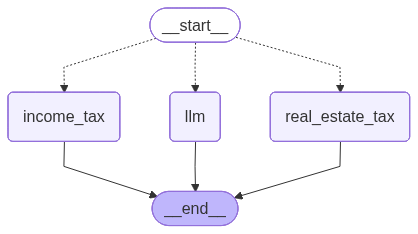

In [43]:
from IPython.display import Image, display

display(Image(graph.get_graph().draw_mermaid_png()))

In [32]:
initial_state = {'query': '소득세란 무엇인가요?'}
graph.invoke(initial_state)

context == [Document(id='4aa2216d-2ac0-4f7b-a902-bae6ff680984', metadata={'source': './documents/income_tax.txt'}, page_content='소득세법\n[시행 2024. 7. 1.] [법률 제19933호, 2023. 12. 31., 일부개정]\n기획재정부 (세제실세제과) 044-215-4312\n기획재정부 (소득세제과) 044-215-4216\n기획재정부 (음식세원과) 044-215-4233\n기획재정부 (소득세과사원조사팀) 044-215-4217  \n\n제1장 총칙\n제1조(목적)\n이 법은 개인의 소득에 대하여 소득의 성격과 납세자의 부담능력 등에 따라 적정하게 과세함으로써 조세부담의 형평을 도모하고 재정수입의 원활한 조달에 이바지함을 목적으로 한다.\n[본조신설 2009. 12. 31.]\n[종전 제1조는 제2조로 이동 2009. 12. 31.]\n제2조(정의)\n① 이 법에서 사용하는 용어의 뜻은 다음과 같다. <개정 2010. 12. 27, 2014. 12. 23, 2018. 12. 31.>\n1. "거주자"란 국내에 주소를 두거나 183일 이상 거소(居所)를 둔 개인을 말한다.\n2. "비거주자"란 거주자가 아닌 개인을 말한다.\n3. "국내법인"이란 법인세법 제2조제1호에 따른 내국법인을 말한다.\n4. "외국법인"이란 법인세법 제2조제3호에 따른 외국법인을 말한다.\n5. "사업자"란 사업소득이 있는 거주자를 말한다.\n6. 제1항에 따른 주소·거소와 비거주자의 구분은 대통령령으로 정한다.\n[본조신설 2009. 12. 31.]\n제3조(납세의무)\n다음 각 호의 어느 하나에 해당하는 개인은 이 법에 따라 각자의 소득에 대한 소득세를 납부할 의무를 진다.\n1. 거주자\n2. 비거주자\n3. 법인\n4. 외국법인은 국내사업소(출場所, 그 밖에 이에 준하는 것을 포함한다. 이하 같다)\n5. 그 밖에 법에 의해 정하는 원천징수의무자\n3. "국세기본법" 제3

{'query': '소득세란 무엇인가요?',
 'context': [Document(id='4aa2216d-2ac0-4f7b-a902-bae6ff680984', metadata={'source': './documents/income_tax.txt'}, page_content='소득세법\n[시행 2024. 7. 1.] [법률 제19933호, 2023. 12. 31., 일부개정]\n기획재정부 (세제실세제과) 044-215-4312\n기획재정부 (소득세제과) 044-215-4216\n기획재정부 (음식세원과) 044-215-4233\n기획재정부 (소득세과사원조사팀) 044-215-4217  \n\n제1장 총칙\n제1조(목적)\n이 법은 개인의 소득에 대하여 소득의 성격과 납세자의 부담능력 등에 따라 적정하게 과세함으로써 조세부담의 형평을 도모하고 재정수입의 원활한 조달에 이바지함을 목적으로 한다.\n[본조신설 2009. 12. 31.]\n[종전 제1조는 제2조로 이동 2009. 12. 31.]\n제2조(정의)\n① 이 법에서 사용하는 용어의 뜻은 다음과 같다. <개정 2010. 12. 27, 2014. 12. 23, 2018. 12. 31.>\n1. "거주자"란 국내에 주소를 두거나 183일 이상 거소(居所)를 둔 개인을 말한다.\n2. "비거주자"란 거주자가 아닌 개인을 말한다.\n3. "국내법인"이란 법인세법 제2조제1호에 따른 내국법인을 말한다.\n4. "외국법인"이란 법인세법 제2조제3호에 따른 외국법인을 말한다.\n5. "사업자"란 사업소득이 있는 거주자를 말한다.\n6. 제1항에 따른 주소·거소와 비거주자의 구분은 대통령령으로 정한다.\n[본조신설 2009. 12. 31.]\n제3조(납세의무)\n다음 각 호의 어느 하나에 해당하는 개인은 이 법에 따라 각자의 소득에 대한 소득세를 납부할 의무를 진다.\n1. 거주자\n2. 비거주자\n3. 법인\n4. 외국법인은 국내사업소(출場所, 그 밖에 이에 준하는 것을 포함한다. 이하 같다)\n5. 그 밖에 법에 의해 

In [33]:
initial_state = {
    'query': '집 15억은 세금을 얼마나 내나요?'
}

graph.invoke(initial_state)

과세표준: 제공해주신 정보만으로는 정확한 과세표준 및 최종 세액을 계산하기 어렵습니다. 특히 종합부동산세의 과세표준 계산 공식과 세율 정보가 누락되어 있습니다.

다만, 사용자님의 주택 공시가격(15억 원)과 제공된 '공정시장가액비율(60%)', 그리고 '공제금액' 정보를 바탕으로 **일반적인 1세대 1주택자의 경우를 가정**하여 예상 세액을 추정해 볼 수 있습니다.

---

**정확한 계산을 위해 필요한 추가 정보:**

*   **주택 소유 현황:** 1세대 1주택자인지, 다주택자인지? (종부세 공제액이 달라집니다.)
*   **연령:** 만 60세 이상인지, 해당된다면 정확한 연령 구간 (60~65세 미만, 65~70세 미만, 70세 이상)
*   **보유기간:** 주택을 얼마나 오래 보유했는지 (1세대 1주택자의 경우 보유기간별 공제도 있습니다 - 최대 50%)
*   **종합부동산세 세율:** 주택분 종합부동산세의 구체적인 세율표가 필요합니다. (제공된 정보에는 "세율 정보가 제시되어 있습니다"라고 되어 있으나, 실제 세율표는 없습니다.)

---

**1세대 1주택자, 만 65세 이상 (연령 공제 30% 가정)의 예상 세액 추정 (2023년 기준):**

**1. 재산세 계산 (종합부동산세 공제를 위함):**

*   **공시가격:** 15억 원
*   **재산세 과세표준:** 15억 원 * 공정시장가액비율 60% = **9억 원**
*   **예상 재산세액:** 9억 원에 대한 재산세는 지방교육세, 도시지역분 등을 포함하여 대략 **300만 원 ~ 400만 원 수준**으로 예상할 수 있습니다. (정확한 금액은 지자체별 조례 및 세액 계산 방식에 따라 달라집니다.)

**2. 종합부동산세 계산:**

*   **공시가격:** 15억 원
*   **1세대 1주택자 기본 공제:** 12억 원 (2023년 기준)
*   **종부세 과세 대상 금액:** 15억 원 - 12억 원 = **3억 원**
*   **종부세 과세표준:** 3억 원 * 공정시장가액비

{'query': '집 15억은 세금을 얼마나 내나요?',
 'answer': '제공해주신 문서와 사용자님의 정보(주택 공시가격 15억 원, 공정시장가액비율 60%)를 바탕으로 종합부동산세를 계산해 드리겠습니다.\n\n종합부동산세는 주택 소유 현황(1세대 1주택자 여부, 다주택자 여부)에 따라 공제 금액과 세율 적용이 달라지므로, 각 경우를 나누어 계산하겠습니다.\n\n---\n\n### **공통 적용 정보:**\n\n*   **주택 공시가격:** 15억 원\n*   **공정시장가액비율:** 60% (제공된 정보에서 인용)\n\n---\n\n### **종합부동산세 계산 단계:**\n\n1.  **과세 대상 금액 산정:** (주택 공시가격 합계액 - 기본 공제액)\n2.  **과세표준 산정:** 과세 대상 금액 × 공정시장가액비율\n3.  **산출세액 계산:** 과세표준에 해당하는 세율 적용\n\n---\n\n### **시나리오별 종합부동산세 계산:**\n\n#### **시나리오 1: 1세대 1주택자인 경우**\n\n*   **1. 과세 대상 금액:**\n    *   1세대 1주택자 기본 공제액: 12억 원\n    *   과세 대상 금액 = 15억 원 - 12억 원 = **3억 원**\n\n*   **2. 과세표준:**\n    *   과세표준 = 3억 원 × 60% = **1억 8천만 원**\n\n*   **3. 산출세액 (2주택 이하 세율 적용):**\n    *   과세표준 1억 8천만 원은 "3억 원 이하" 구간에 해당합니다.\n    *   세율: 1천분의 5\n    *   산출세액 = 1억 8천만 원 × (5/1000) = **90만 원**\n\n*   **참고:** 1세대 1주택자의 경우, 산출된 세액에서 **연령별 공제** (만 60세 이상) 및 **보유기간별 공제** (5년 이상 보유)가 추가로 적용될 수 있으며, 재산세액 공제도 이루어집니다. 이러한 공제들을 적용하면 실제 납부할 세액은 크게 줄어들거나 없을 수 있습니다.\n\n#### *

In [44]:
initial_state = {'query': '떡볶이는 어디가 맛있나요?'}
graph.invoke(initial_state)

{'query': '떡볶이는 어디가 맛있나요?',
 'answer': "떡볶이는 워낙 개인 취향이 강해서 '여기가 최고!'라고 단정하기는 어렵지만, 많은 분들이 좋아하는 유명한 곳들과 특징들을 소개해 드릴게요! 어떤 스타일의 떡볶이를 선호하시는지 알려주시면 더 자세히 추천해 드릴 수도 있습니다.\n\n---\n\n### 1. 전통적인 맛과 분위기를 선호한다면 (시장/골목 떡볶이)\n\n*   **신당동 떡볶이 타운:** 즉석 떡볶이의 성지죠. 여러 가게들이 모여있고, 테이블에서 보글보글 끓여 먹는 재미가 있습니다. 마복림 할머니 떡볶이가 가장 유명하고, 튀김만두, 라면 사리 등을 넣어 먹는 것이 특징입니다.\n*   **통인시장 기름 떡볶이:** 엽전으로 사 먹는 재미가 있는 곳입니다. 국물 없이 고추장 양념과 간장 양념으로 볶아낸 떡볶이로, 독특하고 중독성 있는 맛을 자랑합니다.\n*   **남대문시장/광장시장 떡볶이:** 시장 특유의 정겨운 분위기에서 서서 먹거나 간이 의자에 앉아 먹는 떡볶이입니다. 대부분 칼칼하고 달콤한 국물 떡볶이 스타일이 많습니다.\n*   **망원시장 떡볶이:** 망원동에 위치한 시장으로, 저렴하고 맛있는 떡볶이 집들이 많습니다. 예를 들어 '맛있는집' 같은 곳은 현지인들에게 인기가 많습니다.\n\n### 2. 프랜차이즈 떡볶이 (다양한 맛과 접근성)\n\n*   **엽기떡볶이 (엽떡):** 매운 떡볶이의 대명사죠. 아주 매운 맛을 선호하는 분들에게 추천하며, 치즈, 주먹밥 등과 함께 먹으면 더욱 맛있습니다.\n*   **신전떡볶이:** 엽떡만큼이나 매운 맛으로 유명하며, 얇은 쌀떡과 특유의 후추 맛이 특징입니다. 튀김(특히 오뎅튀김)과 함께 먹는 조합이 좋습니다.\n*   **두끼:** 즉석 떡볶이 뷔페입니다. 다양한 떡, 사리, 소스를 원하는 대로 조합하여 나만의 떡볶이를 만들어 먹을 수 있습니다. 튀김, 어묵, 볶음밥까지 해결 가능합니다.\n*   **청년다방:** 긴 떡을 사용하는 프리미엄 즉석 떡볶이로, 통오징어튀김, 차돌